In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q qiskit[visualization]
!pip install -q qiskit_aer

In [3]:
# baby impl only for a^x (mod15)

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from fractions import Fraction
from math import gcd


# --- Helper function to create the Controlled-U gate ---
# This function manually builds the circuit for the modular multiplication
# for the specific case of a=7, N=15.
def c_amod15(a, power):
    """Controlled multiplication by a mod 15"""
    if a not in [2,7,8,11,13]:
        raise ValueError("'a' must be 2,7,8,11 or 13")
    U = QuantumCircuit(4)
    for iteration in range(power):
        if a in [2,13]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [7,8]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a == 11:
            U.swap(1,3)
            U.swap(0,2)
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U


# Step 1
# ----SET UP ---------
# set up the two registers first register is main register the |x> that is part of a^x mod N
# second register is actually an aux register which need not be measured but that transfer phase to the the first one

N = 15 # number to factor
a = 7 # pick a random number such that 1<a<N

# Step 2
# ----BUILD CIRCUIT ---------
# N = 15 so 2^4 = 16 hav 2n qubits for more precision. n qubits are enuf per algo
n_main_register = 8
n_aux = 4 # logN

qc = QuantumCircuit(n_main_register + n_aux, n_main_register) # measure only main register, 2nd param is classical bits

for qubit in range(n_main_register):
    qc.h(qubit)

# initialize the aux register to 1 state which LSB = 1 rest are 0. like 000001
qc.x(n_main_register+n_aux-1)

# Step 3
# modular exponentiation using controlled U gates

for q in range(n_main_register):
    #The quantum circuit for Shor's algorithm doesn't compute a^x directly.
    # Instead, it breaks the calculation down using the binary representation of x. 
    # Any number x can be written as a sum of powers of 2 (e.g., 13=8+4+1=2^3 + 2^2 + 2^1 + 2^0)
    # power = pow(a, 2**j, N), is not calculating 7^13   directly. Instead, it's pre-calculating all the necessary 
    #"building block" terms—the powers of 2—that we might need. Let's trace the loop for our example (a=7, N=15):
    # j=0: power = pow(7, 2**0, 15) → power = pow(7, 1, 15) → power = 7
    # j=1: power = pow(7, 2**1, 15) → power = pow(7, 2, 15) → power = 4
    #j=2: power = pow(7, 2**2, 15) → power = pow(7, 4, 15) → power = 1
    #j=3: power = pow(7, 2**3, 15) → power = pow(7, 8, 15) → power = 1
    #These four values (7, 4, 1, 1) are the only results we'll ever need to calculate 7^x(mod15) for any x up to 15.
    # power = pow(a,2**j,N) # classical modulo its a python optimizatiomn
    #Cmultiplication dint work so built out custom gate only for this number combination - will generalize
    
    qc.append(c_amod15(a, 2**q), [q] + list(range(n_main_register, n_main_register + n_aux))) 
    # aux qubits are 8, 9, 10, 11. range is from to. append is qc.append(gate, whichbitstoappend)
    
# Step 4
# apply QFT-1 to main register

qft_inv_gate = QFTGate(n_main_register).inverse()
qc.append(qft_inv_gate, range(n_main_register))

# Step 5
# measure the main register
qc.measure(range(n_main_register), range(n_main_register))

# Step 6 run all of it in a simulator

aer_sim = AerSimulator()
qc_t = transpile(qc, aer_sim)

result = aer_sim.run(qc_t, shots=1024).result()
counts = result.get_counts() # produces binary rep

# Step 7 classical post processing

measured_str = max(counts, key=counts.get) # find most occuring string
m = int(measured_str, 2) # base 2 convert from binary to string
print(f"Most frequent measurement result (m): {m}")

phase = m / (2**n_main_register)
print(f"Estimated Phase (θ): {phase}")

frac = Fraction(phase).limit_denominator(N)
s, r = frac.numerator, frac.denominator
print(f"Guessed Fraction (s/r): {s}/{r}")

if r % 2 != 0:
    print(f" r is not even {r} so try another 'a' and rerun")
else:
    factor1 = gcd(pow(a, r//2)-1, N)
    factor2 = gcd(pow(a, r//2)+1, N)

    if factor1 !=1 and factor1 !=N:
        print(f"Found a factor: {factor1}")
        
    if factor2 !=1 and factor2 !=N:
        print(f"Found a factor: {factor2}")


    if (factor1 == 1 or factor1 == N) and (factor2 == 1 or factor2 == N):
        print("Could not find a non-trivial factor with this measurement. Try running again.")


Most frequent measurement result (m): 64
Estimated Phase (θ): 0.25
Guessed Fraction (s/r): 1/4
Found a factor: 3
Found a factor: 5


In [11]:
# lets build something more generic
import numpy as np
import math
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from fractions import Fraction
from math import gcd
import random

def build_shor_circuit(N, n_main_register, a=None):
    """ 
    N = number to factor
    a = random number, can pass or will be chosen randomly within the fn
    n_main_register = number of bits in the first register to use
    returns 
    """ 
    if a is None:
        while True:
            a = random.randrange(2, N)
            if gcd(a, N) == 1:
                break

    elif gcd(a,N)!=1:
        print(f"choose another 'a' as {a} as its already a factor of N")
        
    # precompute the a powers
    print(f"a is {a}")
    apower2powerk_list = [pow(a, 2**k, N) for k in range(n_main_register)]
    # a^x = (a^2^0)^x0 . (a^2^1)^x1 . (a^2^2)^x2 . so on (mod N)
    # this is the binary explansion of x using powers of 2
    # any num x = x0.2^0. + x1.2^1 + x2.2^2 + ... so on
    # subsititue this in a^x.
    # calculate x prior so quantum part can a^x
    print("apower2powerk_list ",apower2powerk_list)

    # step 1 prepare cricuit
    main_register = QuantumRegister(n_main_register, "Main register")
    n_aux = math.ceil(math.log2(N))
    print(f" n_aux is {n_aux}")
    aux_register = QuantumRegister(n_aux, "Aux register")
    classic_register = ClassicalRegister(n_main_register, "Classic Register")
    qc = QuantumCircuit(main_register, aux_register,classic_register)

    # step 2 make LBS 1 and make auxRegister init to 1
    qc.x(aux_register[0]) # LBS so this reg is made 1 at init
    # apply H to main register bits so they are in super position
    qc.h(main_register)

    # step 3 apply the U fn and entangle  main and aux register qubits
    for k in range(n_main_register):
        apower2powerk = apower2powerk_list[k]

        if apower2powerk%N == 1:
            continue

        multiplier_gate = create_mul_gate(apower2powerk, n_aux, N)
        print(f"created gate for apower2powerk {apower2powerk}")
        controlled_multiplier_gate = multiplier_gate.control()
        #print("gate control to target ",[main_register[k]] + aux_register[:])
        qc.append(controlled_multiplier_gate, [main_register[k]] + aux_register[:]) # control qubit from main when its 1 to all aux qubits

    # step 4 apply the QFT-1 to main register
    qft_inv_gate = QFTGate(n_main_register).inverse()
    qc.append(qft_inv_gate, range(n_main_register))

    # step 5 measure main register
    qc.measure(main_register, classic_register)

    return qc, a


def create_mul_gate(apower2powerk, n_aux, N):
    """
    apower2powerk - # a^x = (a^2^0)^x0 . (a^2^1)^x1 . (a^2^2)^x2 . so on (mod N)
    # this is the binary explansion of x using powers of 2
    # any num x = x0.2^0. + x1.2^1 + x2.2^2 + ... so on
    # subsititue this in a^x.
    # calculate x prior so quantum part can a^x
    n_aux - aux bits number
    N - num to fact
    returns gate
    """
    dim = 2**n_aux
    U = np.zeros((dim, dim), dtype=complex)
    print(f"creating gate with dim {dim}")
    for y in range(dim):
        if y < N:
            target = (apower2powerk*y) % N
            U[target, y] = 1.0
        else:
            U[y, y] = 1.0

    gate = UnitaryGate(U, label="U operator")
    return gate


def run_shor_sim(qc):

    aer_sim = AerSimulator()
    qc_t = transpile(qc, aer_sim)

    result = aer_sim.run(qc_t, shots=1024).result()
    counts = result.get_counts() # produces binary rep

    return counts

################################### MAIN PROGRAM ##############################

N = 15
n_main_register = 8
n_aux=4
a = None # a = 7 this optional use for testing

qc, a = build_shor_circuit(N, n_main_register, a)
counts = run_shor_sim(qc)

# classical post processing

measured_str = max(counts, key=counts.get) # find most occuring string
m = int(measured_str, 2) # base 2 convert from binary to string
print(f"Most frequent measurement result (m): {m}")

phase = m / (2**n_main_register)
print(f"Estimated Phase (θ): {phase}")

frac = Fraction(phase).limit_denominator(N)
s, r = frac.numerator, frac.denominator
print(f"Guessed Fraction (s/r): {s}/{r}")

if r % 2 != 0:
    print(f" r is not even {r} so try another 'a' and rerun")
else:
    factor1 = gcd(pow(a, r//2)-1, N)
    factor2 = gcd(pow(a, r//2)+1, N)

    if factor1 !=1 and factor1 !=N:
        print(f"Found a factor: {factor1}")
        
    if factor2 !=1 and factor2 !=N:
        print(f"Found a factor: {factor2}")


    if (factor1 == 1 or factor1 == N) and (factor2 == 1 or factor2 == N):
        print("Could not find a non-trivial factor with this measurement. Try running again.")



a is 4
apower2powerk_list  [4, 1, 1, 1, 1, 1, 1, 1]
 n_aux is 4
creating gate with dim 16
created gate for apower2powerk 4
Most frequent measurement result (m): 128
Estimated Phase (θ): 0.5
Guessed Fraction (s/r): 1/2
Found a factor: 3
Found a factor: 5


# for the matrix U created for the case: create_mul_gate(a^2^k=7, n_aux=4, N=15)

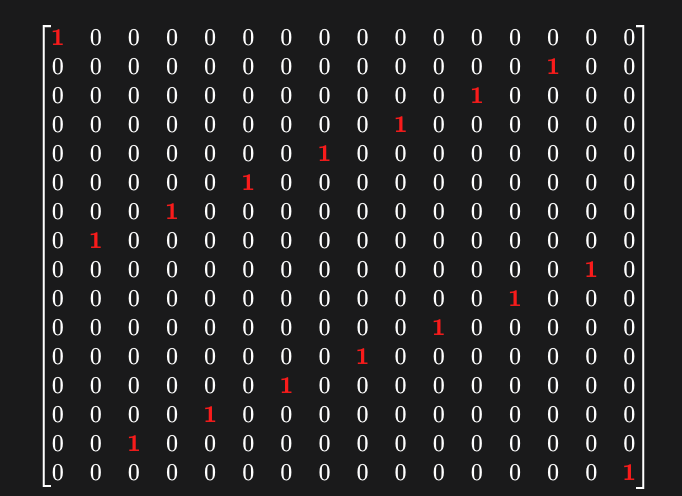


# How to read this

**if the input is state 1 (|0001>) then look at the 2nd column (as matrices start at (0,0)) and find the the row index in this case it is 7. so |0001> --U--> |0111>. Matrix is only used to find the corress index but we are dealing with 4 bit system so 7 is rep as |0111>.**



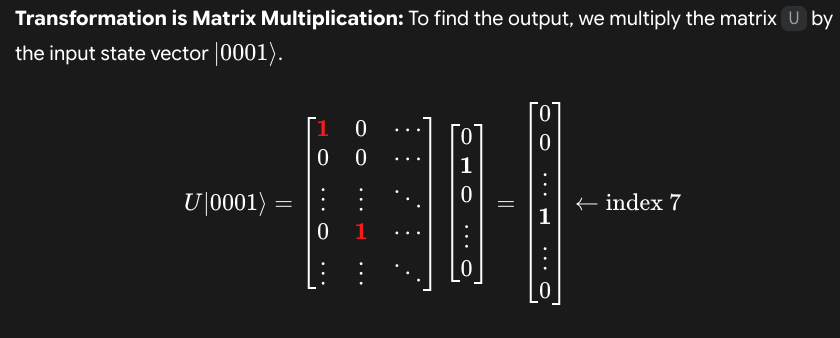


# A note on precalculation of apower2powerk_list (a^2^k_list) [more on this in Step 1 below]

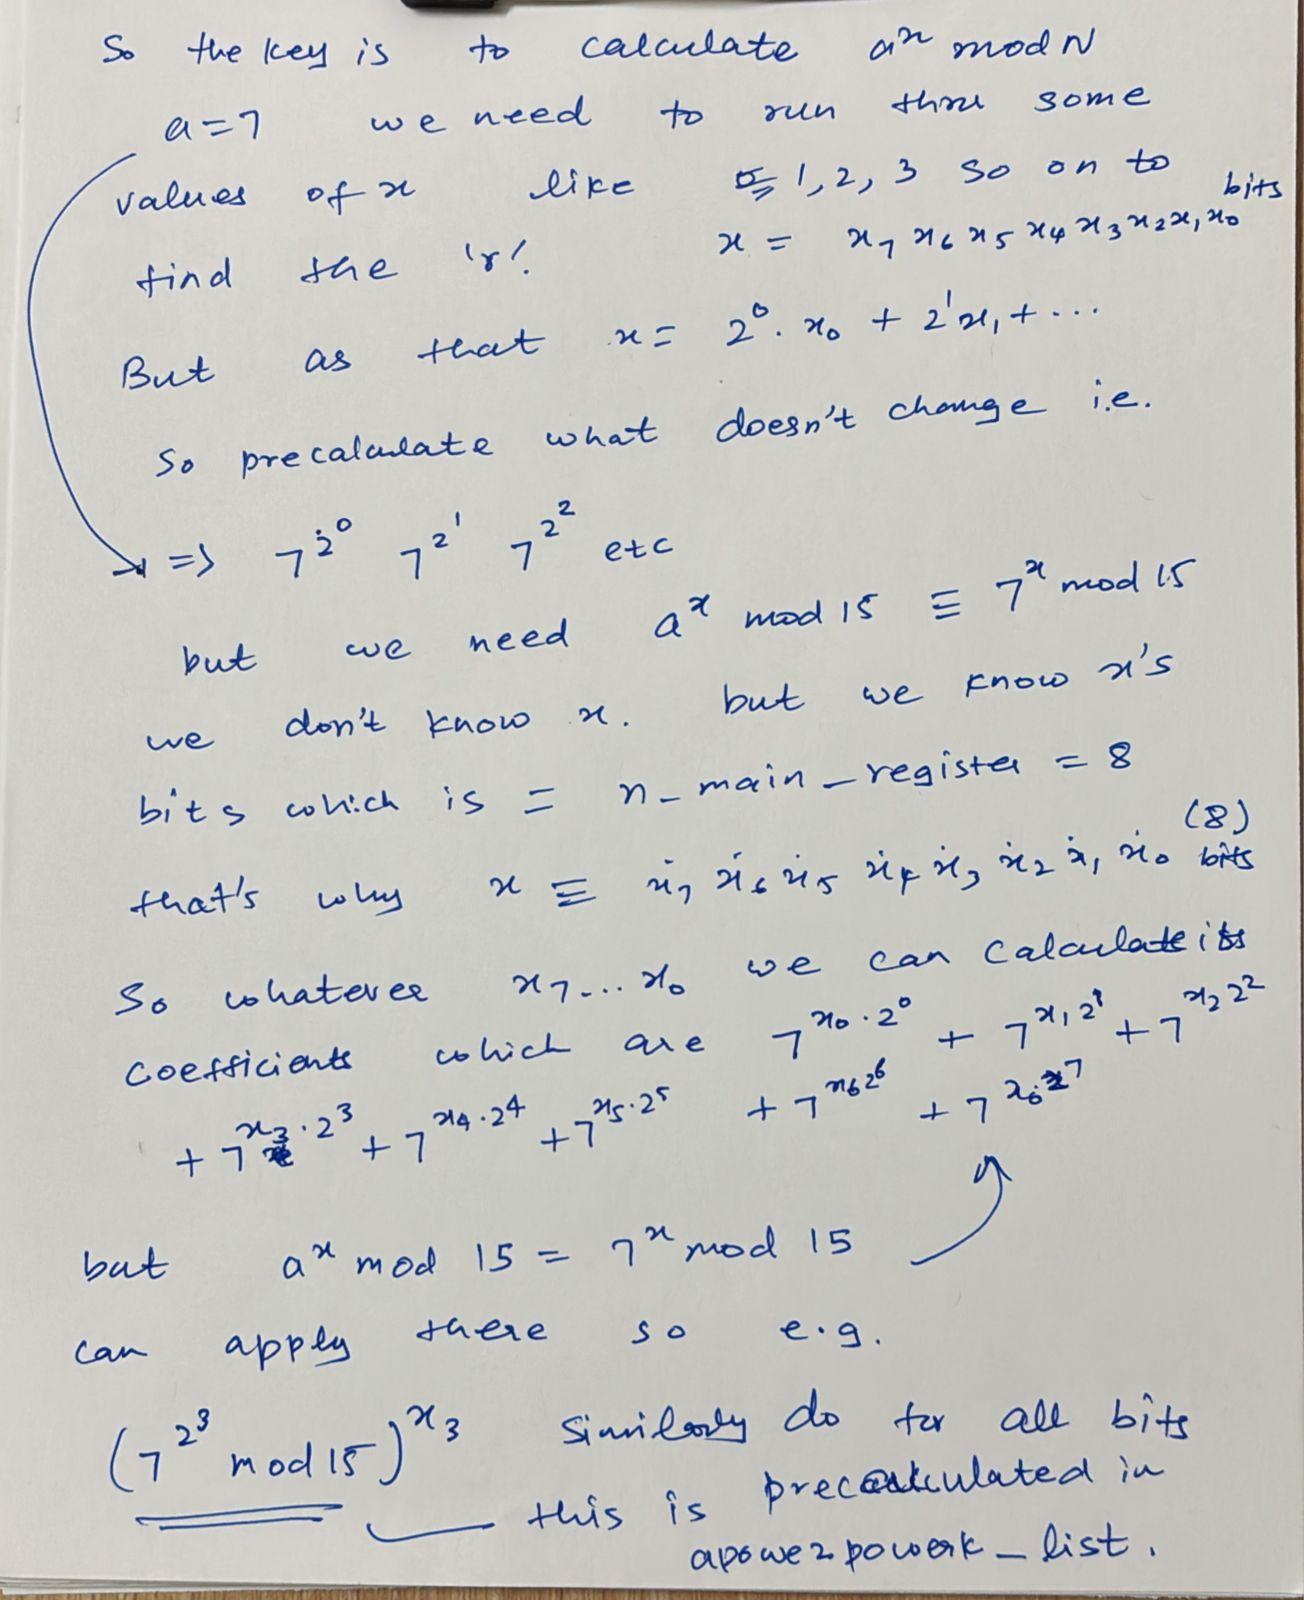


# Explain how the controlled gate is built step by step

# Outcome needed

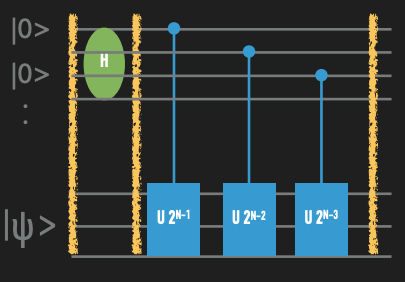

# Step 1: Classical Set up
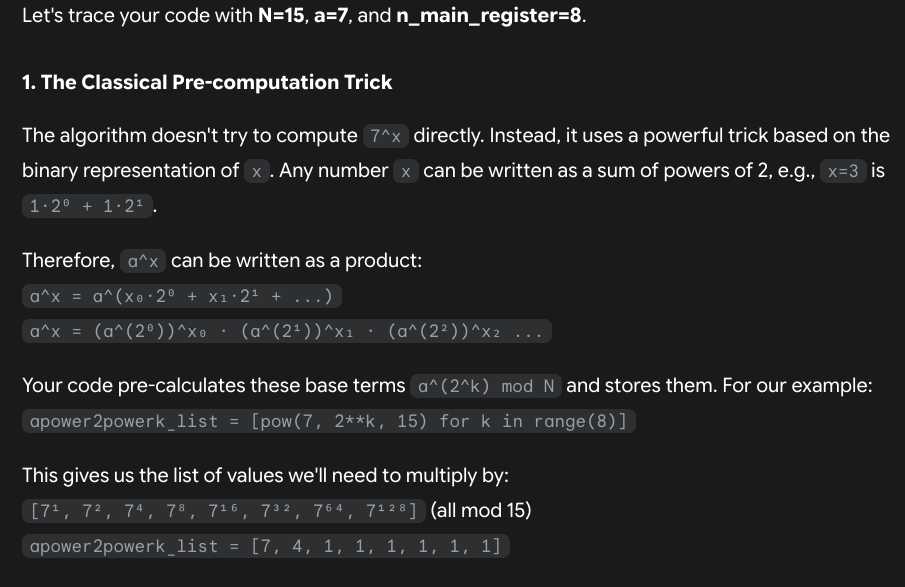

# Step 2: Set up Quantum circuit
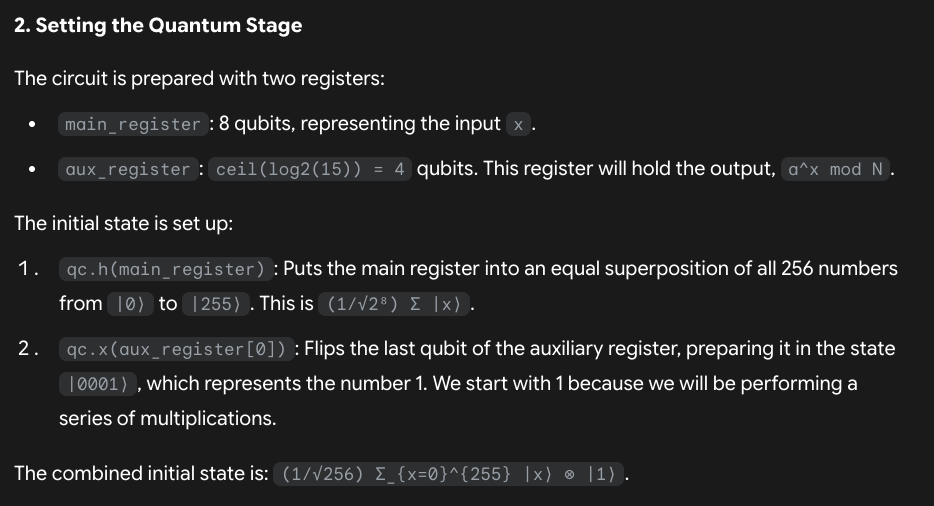

# Step 3: Create the mul gate [Changes |y> e.g. |0001> --> |0111>]



**|y> is the state of main register at any point. First call to createmul will create a gate which changes say|0001> -> |0111> now |y> value becomes |7>. Note that |y> represents the aux register.**



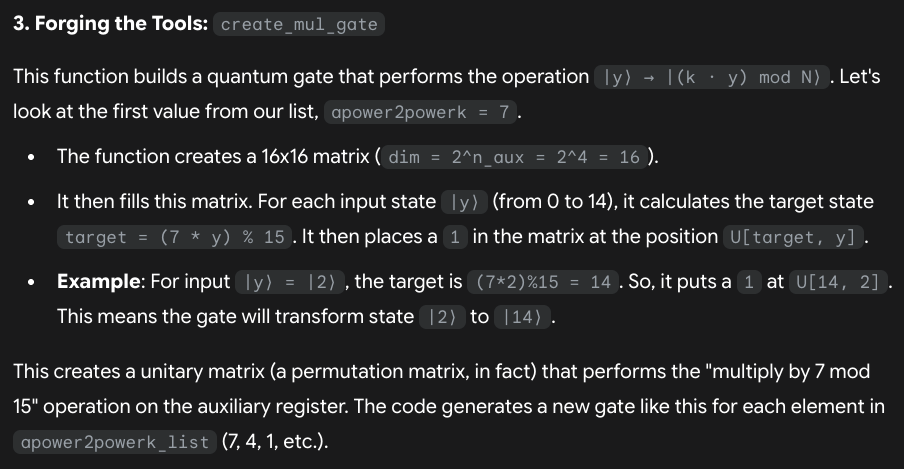

# Step 4: Assembling all the gates U2N-1 from main (control) to aux (target) 
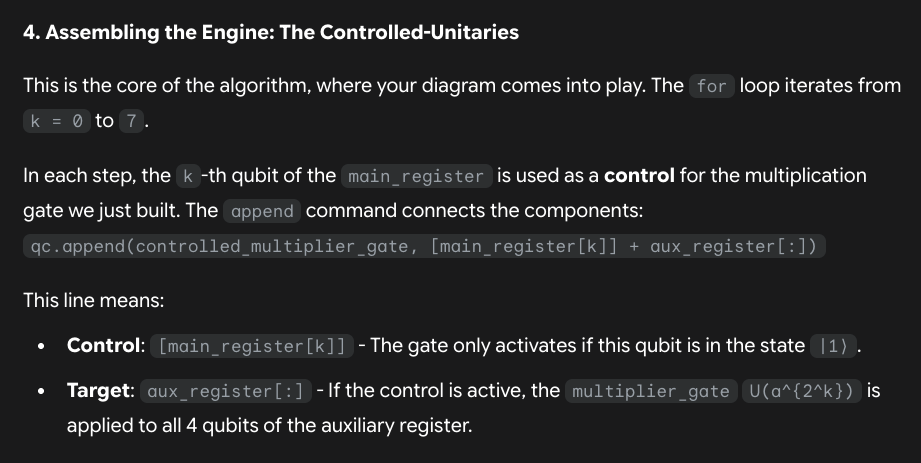

# Step 5: A concrete example
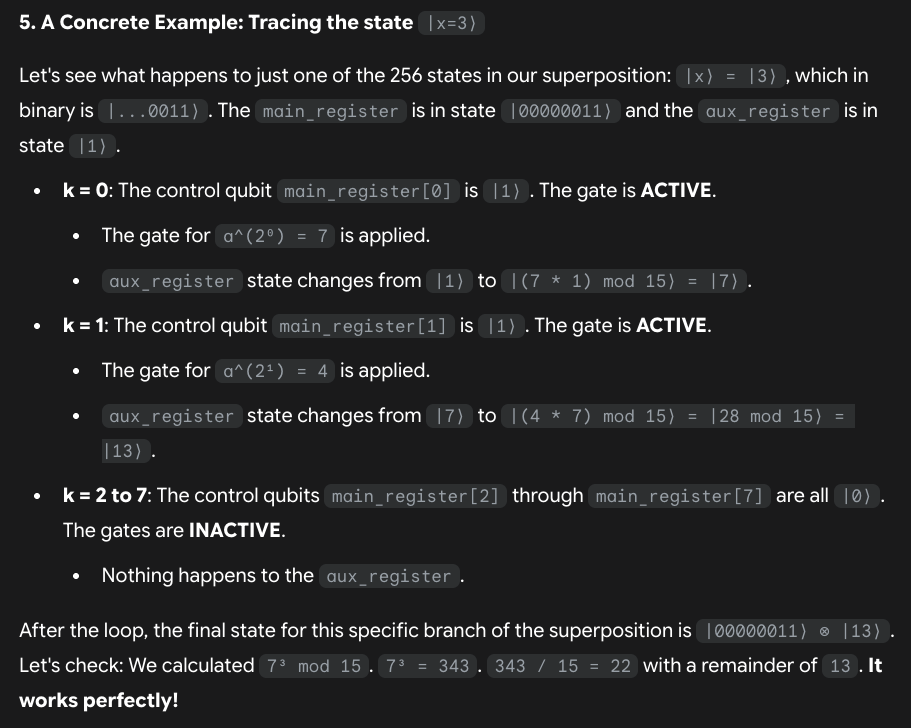

# Step 6: Final state before QFT-1
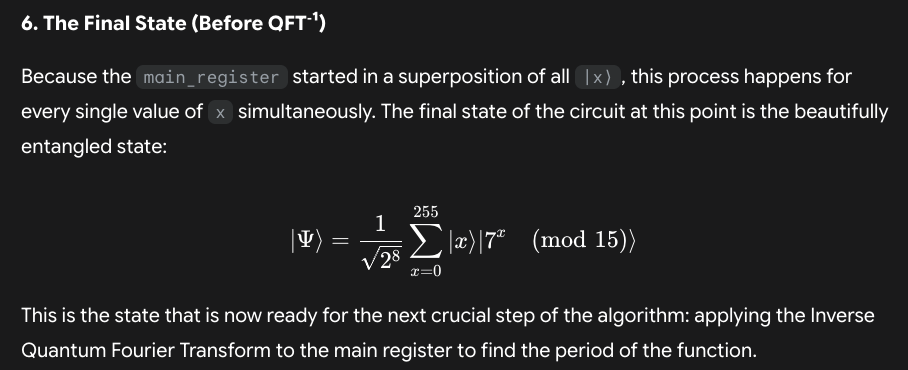

# More context on |x> vs |y>
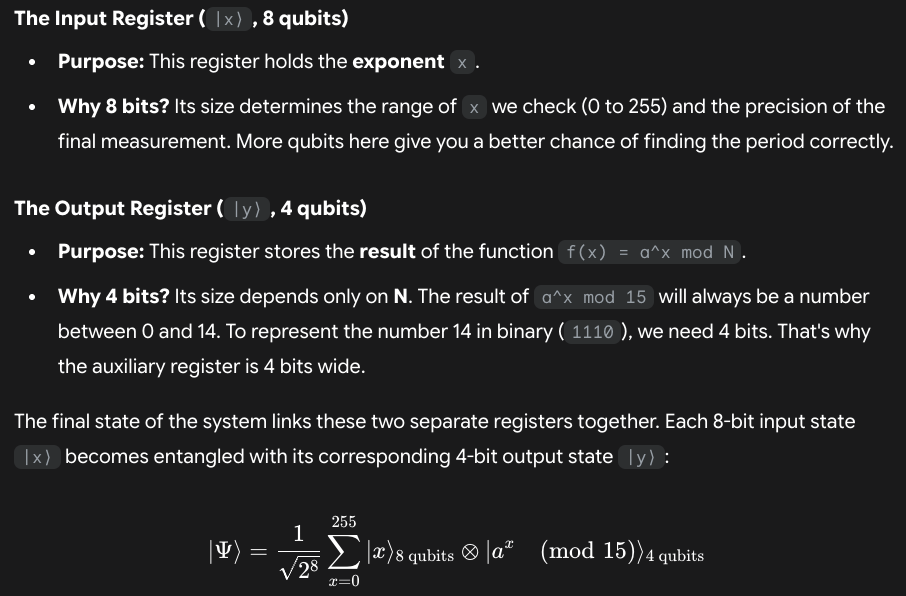


# My QFT/QPE notes vs Shor's Algorithm here - The confusion of |y> bit size
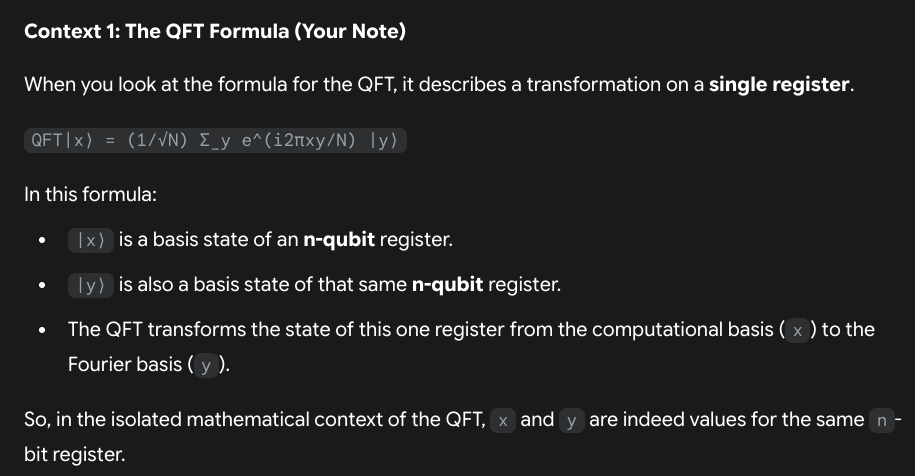

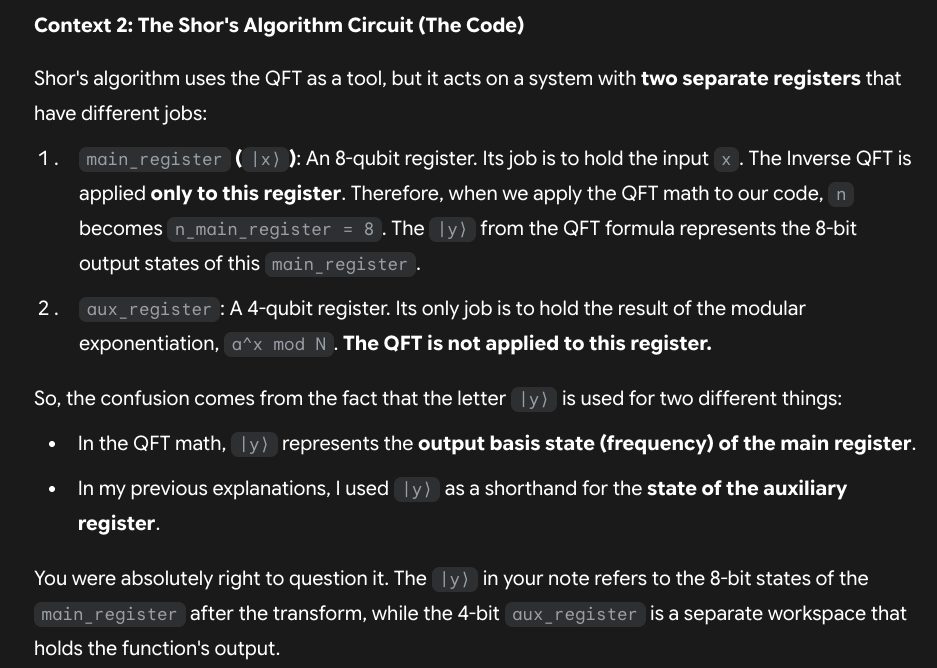

# The real magic - The Phase kickback. How did |x> change if all our operations are only on |y>?

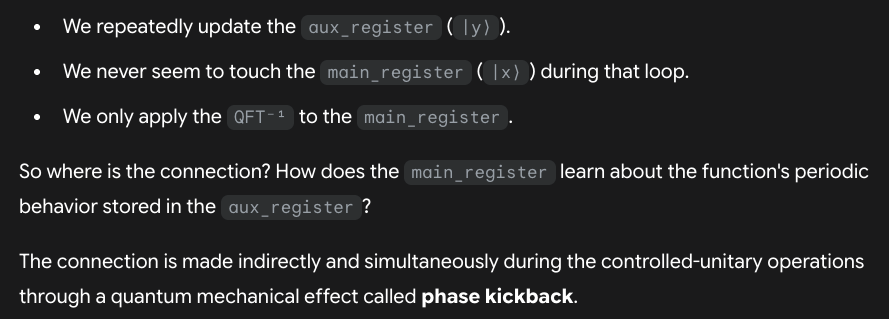

# Wow just look at |t> and how it really transfers the phase to |+>

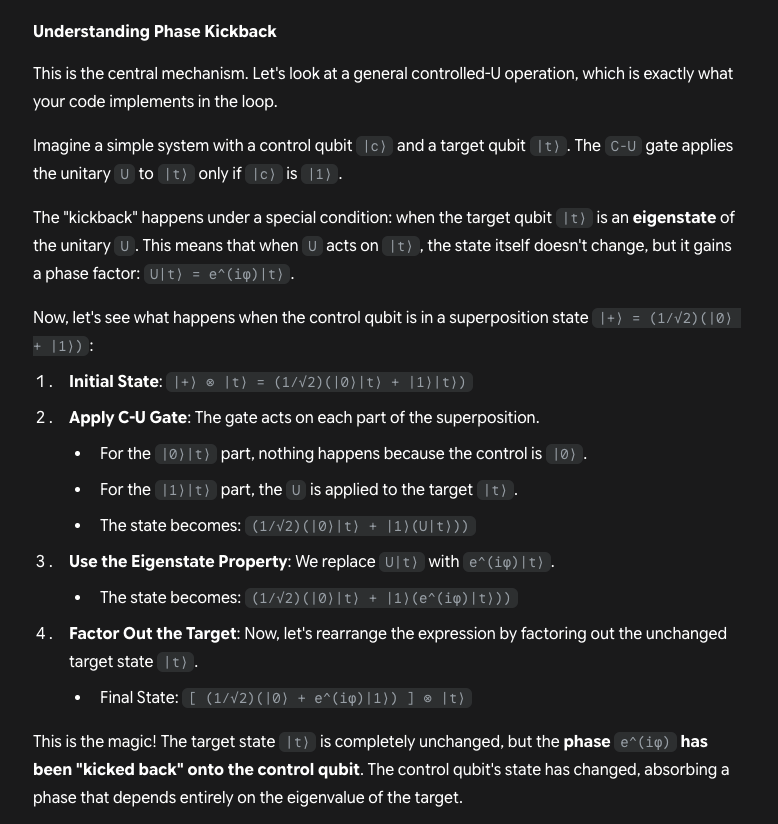

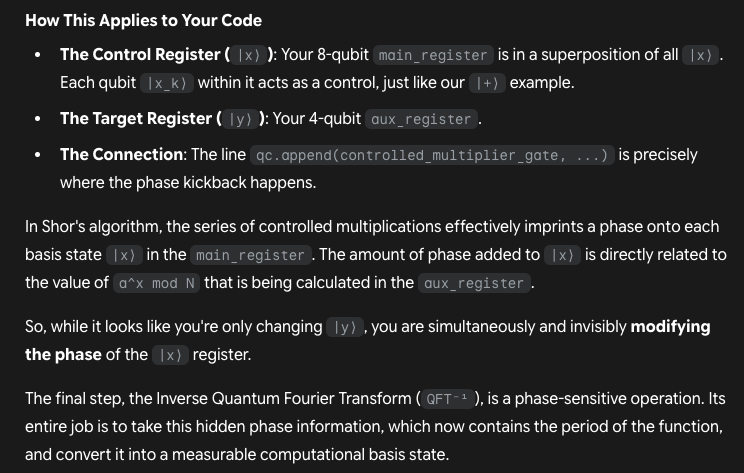

# Step 7: Now apply QFT-1 what happens?
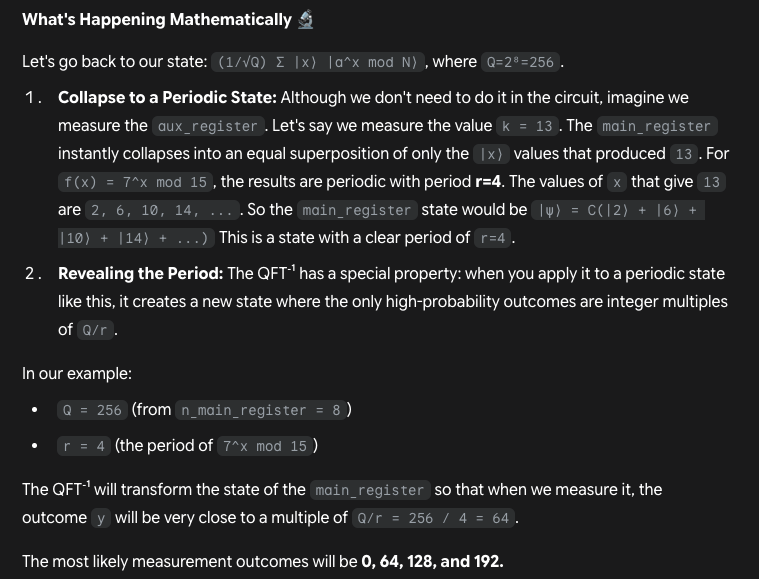

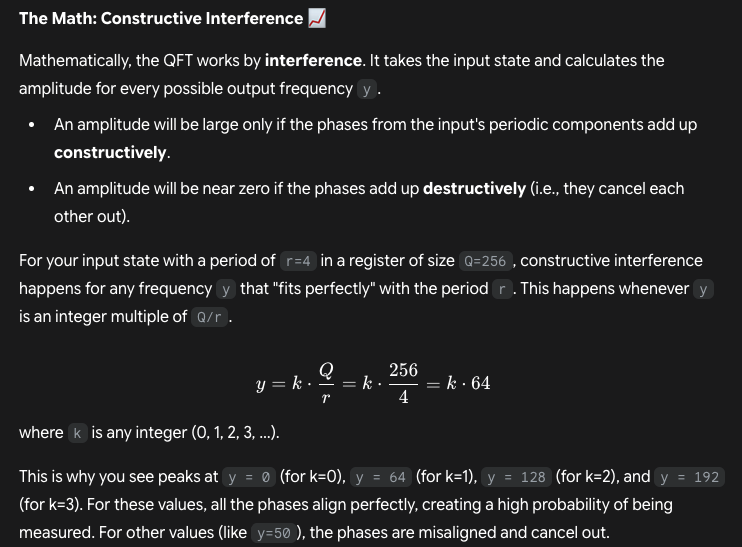
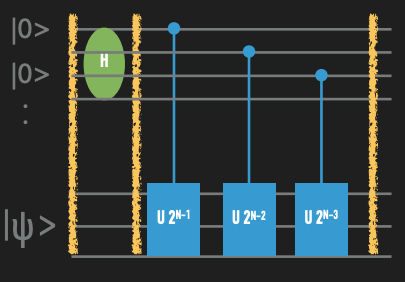